#**Image Captioning**
*  Converting Image to a text.
*   Works as visual Aid for blind people.




In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
import string
import json
import tensorflow
from time import time
import pickle
from keras.applications.vgg16 import VGG16
from keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from keras.preprocessing import image
from tensorflow.keras.models import Model, load_model
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
from keras.layers import Input, Dense, Dropout, Embedding, LSTM
from keras.layers import Add  # Capital A

In [105]:


# print("TensorFlow version:", tf.__version__)
# print("Keras version:", tf.keras.__version__)
# print("Using keras from:", keras.__file__)

import tensorflow as tf
print("TF:", tf.__version__)
print("tf.keras:", tf.keras.__version__)
print("tf.keras path:", tf.keras.__file__)


TF: 2.18.0
tf.keras: 3.8.0
tf.keras path: /usr/local/lib/python3.11/dist-packages/keras/_tf_keras/keras/__init__.py


In [4]:
!dir

In [5]:
# read text captions

def readTextFile(path):
    with open(path) as f:
        caption = f.read()
    return caption

In [6]:
captions = readTextFile('/kaggle/input/flicker/captions.txt')

In [7]:
captions=captions.split('\n')[:-1]   # i am only taking the values till n-2 at the end because last string was empty in it

In [8]:
captions[-1]  # it is the last string that i had so it means i am taking all the captions

'997722733_0cb5439472.jpg,A rock climber practices on a rock climbing wall .'

In [9]:
len(captions)

40456

In [10]:
captions[161]

'1042020065_fb3d3ba5ba.jpg,A boy in a green shirt is looking down at many inflatable boats .'

In [11]:
desc={} # making a dictionary to store the captions for each image as a key(image_path) value(each image 5 captions) pair

In [12]:
for x in captions:
    image_info=x.split(',')  # as they are splitted by ,
    image_name,image_captions=image_info[0],image_info[1]  
    
    if desc.get(image_name) is None:    # as by deafault it returns the none value of a key
        desc[image_name]=[]
    desc[image_name].append(image_captions)

In [13]:
desc['1000268201_693b08cb0e.jpg']

['A child in a pink dress is climbing up a set of stairs in an entry way .',
 'A girl going into a wooden building .',
 'A little girl climbing into a wooden playhouse .',
 'A little girl climbing the stairs to her playhouse .',
 'A little girl in a pink dress going into a wooden cabin .']

In [14]:
import cv2

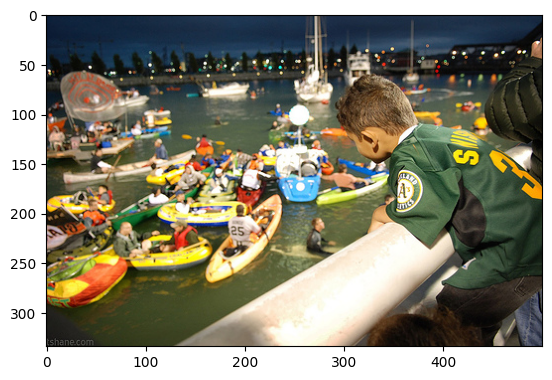

['A boy in a green shirt is looking down at many inflatable boats .',
 'A boy in a green shirt watches kayakers .',
 'A boy looks over a railing at the many boats and rafts below in the water .',
 'A young boy overlooking a crowd of inflatable boats .',
 'A young boy wearing a jersey looks down over a ledge at many boats in the water .']

In [15]:
path = '/kaggle/input/flicker/Flickr8k_Dataset/Flicker8k_Dataset/1042020065_fb3d3ba5ba.jpg'
# plt.imshow(cv2.imread(path))


img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   
plt.imshow(img)
plt.show()

desc['1042020065_fb3d3ba5ba.jpg']

2.
**plt.imshow(cv2.imread(path))**


* cv2.imread(path)
Reads the image from disk into memory using OpenCV.

1. It returns a NumPy array of pixel values.

2. Important: OpenCV reads images in BGR color order, but matplotlib expects RGB, so colors may look weird unless you convert:


**img = cv2.imread(path);img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB);plt.imshow(img)**



* plt.imshow(...)
Displays the image inside your notebook using matplotlib.


3.
plt.show()
Actually renders the image on the screen.

In Jupyter/Kaggle notebooks, this makes the plot/image appear in the cell output.

# Data Cleaning
**HERE**

* Not removing stopwords
* Not doing stemming
* Only removing numbers, punctuations





1️⃣ Stopwords are important in captions
2️⃣ Stemming would distort natural words
3️⃣ Only punctuation and numbers are removed

* Punctuation: Often unnecessary for tokenizing captions; removing it avoids tokens like "dog." and "dog" being treated differently.

* Numbers: Usually rare and not critical in Flickr8k captions; removing them simplifies vocabulary.

In [16]:
import re

In [17]:
def clean_text(sentence):
    sentence = sentence.lower()
    sentence = re.sub('[^a-z]+',' ', sentence)
    sentence = sentence.split()    ## remember if we don't pass anything in it then by deafault it would be splitting on the basis of whitespace here
    sentence = [s for s in sentence if len(s) > 1]
    sentence = ' '.join(sentence)
    return sentence

# above we are not taking 1 word sentences as they won't be contributing much in the dataset so that's why word len>1 and word about it read from chatgpt as saved there

In [18]:
# cleaning all captions

In [19]:
for key, caption_list in desc.items():
    for i in range(len(caption_list)):
        caption_list[i]=clean_text(caption_list[i])

In [20]:
desc['1042020065_fb3d3ba5ba.jpg']

['boy in green shirt is looking down at many inflatable boats',
 'boy in green shirt watches kayakers',
 'boy looks over railing at the many boats and rafts below in the water',
 'young boy overlooking crowd of inflatable boats',
 'young boy wearing jersey looks down over ledge at many boats in the water']

In [21]:
len(desc)

8092

In [22]:
# write the data to text file
with open('/content/descriptions_1.txt','w') as f:
    f.write(str(desc))

# here this str converts that dictionary into a string format dictionary which we will store as it is the file path written in open



# Vocabulary
* It is a set of all possible unique words that model can predict.





In [23]:
import json

In [24]:
descriptions = None

with open('/kaggle/input/flicker/descriptions_1.txt') as f:
    descriptions = f.read()
json_acceptable_string = descriptions.replace("'","\"")
descriptions = json.loads(json_acceptable_string) # converting json string in the form of python dictionary

Actually above we are trying to convert that string into python dictionary as it was before and for it firstly that string should be in valid json string format(because if it is not then with the help of json we won't be able to convert that string in the python dictionary) and in the valid json string there is ""(double quote) instead of ''(single quote) so that is why replaced '-->" and further prefer chatgpt in the conversation that we were doing there

In [25]:
# descriptions  
# u can print it to see that it is same as previous

In [26]:
# descriptions
print(type(descriptions))

<class 'dict'>


In [27]:
len(descriptions)  # as u can see before i had 8092 photos in it but one gone somewhere and it is that one whose value i am trying to print below and it is that image which we printed above that is of that boy

8091

In [28]:
print(descriptions.get('1042020065_fb3d3ba5ba.jpg'))

None


In [29]:
# Vocab

vocab = set()
for key in descriptions.keys():
    [vocab.update(sentence.split()) for sentence in descriptions[key]]

print("Vocab Size(unique words In Vocab) : %d"% len(vocab))

Vocab Size(unique words In Vocab) : 8257


vocab.update(sentence.split())
is working with a Python set, and .update() is a set method.


🔹 What .update() does for a set

.update(iterable) takes an iterable (like a list, tuple, or another set) and adds all its elements to the set.

Unlike .add(), which adds a single item, .update() can add multiple items at once.

Example
vocab = set()
vocab.update(['a', 'black', 'dog'])
print(vocab)   # {'dog', 'black', 'a'}

vocab.update(['a', 'white', 'cat'])
print(vocab)   # {'dog', 'black', 'a', 'white', 'cat'}


Notice "a" wasn’t duplicated.

Why use .update() here?

You’re building a vocabulary of all unique words in the captions dataset.

Using .update() is efficient because it adds multiple words at once and handles duplicates automatically.

In [30]:
vocab = set()
vocab.update(["hello", "apple"])
vocab.update(["hello"])
vocab.update(["hi"])
print(vocab)

{'hi', 'apple', 'hello'}


In [31]:
descriptions.get('1042020065_fb3d3ba5ba.jpg')

In [32]:
# Total No of words across all the sentences
total_words = []

# for key in descriptions.keys():
    # [total_words.append(i)  for i in sentence.split() for sentence in descriptions[key]]
for key in descriptions.keys():
    [total_words.append(i) for des in descriptions[key] for i in des.split()]

print("Total Words %d"%len(total_words))

Total Words 357791


# remember above the commented for loop with list comprehension is wrong because "In Python list comprehensions, the for clauses are evaluated left to right." . so, please remember it as a concept

In [33]:
len(total_words), type(total_words)

(357791, list)

In [34]:
# filter words from vocab according to certain threshold frequency
import collections
counter = collections.Counter(total_words)  ## counter counts the frequency of each word present in the total_words list and gives a dictionary 
frq_cnt = dict(counter)  # here it converts that dictionary into a normal python dictionary 
print(len(frq_cnt.keys())) 
# print(frq_cnt)

8257


In [35]:
# sort the dictionary according to the freq count

sorted_freq_cnt = sorted(frq_cnt.items(), reverse = True, key=lambda x:x[1])

# filter
threshold =  10
sorted_freq_cnt = [x for x in sorted_freq_cnt if x[1]>threshold]
total_words = [x[0] for x in sorted_freq_cnt]

1️⃣ frq_cnt.items()

If frq_cnt is a dictionary, .items() returns a list-like view of (key, value) pairs.

Example:

frq_cnt = {'apple': 4, 'banana': 2, 'orange': 5}
print(frq_cnt.items())
# dict_items([('apple', 4), ('banana', 2), ('orange', 5)])

2️⃣ key=lambda x: x[1]

The key parameter in sorted() tells Python what value to sort by.

Here, each x is a (key, value) tuple from the dictionary.

x[0] → the dictionary key (e.g., 'apple')

x[1] → the dictionary value (e.g., 4)

So lambda x: x[1] means: "Sort by the value of the dictionary item".

3️⃣ reverse=True

By default, sorted() sorts in ascending order.

reverse=True flips it to descending order.

Since we’re sorting by frequency counts, this makes the most frequent item come first.

4️⃣ Wrapping with sorted(...)

sorted() takes any iterable and returns a new sorted list.

In [36]:
#sorted_freq_cnt
print(len(total_words)) # 1800 unique words filter, this is going to be new vocab size

1800


In [37]:
descriptions.get('1042020065_fb3d3ba5ba.jpg')

# Train/Test Data

In [38]:
len(descriptions.keys()), len(descriptions.values())   # remember this .values giving me a list of values

(8091, 8091)

In [39]:
train_file_data = readTextFile('/kaggle/input/flicker-text/Flickr_8k.trainImages.txt')
test_file_data = readTextFile('/kaggle/input/flicker-text/Flickr_8k.testImages.txt')

In [40]:
train = [row.split('.')[0] for row in train_file_data.split('\n')[:-1]]
test = [row.split('.')[0] for row in test_file_data.split('\n')[:-1]]

1️⃣[:-1]
Means "take all elements except the last one".

2️⃣ Why skip the last one?
In many datasets (including Flickr8k's Flickr_8k.trainImages.txt and Flickr_8k.testImages.txt), the text file ends with a newline after the last image name.

In [41]:
# train

In [42]:
len(train), len(test)

(6000, 1000)

In [43]:
print(descriptions.get('1000268201_693b08cb0e.jpg'))

None


In [44]:
train[:5]

['2513260012_03d33305cf',
 '2903617548_d3e38d7f88',
 '3338291921_fe7ae0c8f8',
 '488416045_1c6d903fe0',
 '2644326817_8f45080b87']

In [45]:
# Prepare Description for the Training Data
# Tweak - Add <s> and <e> token to our training data
train_descriptions = {}
for img_id in train:
    train_descriptions[img_id] = []
    for cap in descriptions[img_id]:
        cap_to_append = "startseq " + cap + " endseq"
        train_descriptions[img_id].append(cap_to_append)

In [46]:
train_descriptions["1000268201_693b08cb0e"]

['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
 'startseq girl going into wooden building endseq',
 'startseq little girl climbing into wooden playhouse endseq',
 'startseq little girl climbing the stairs to her playhouse endseq',
 'startseq little girl in pink dress going into wooden cabin endseq']

# Transfer Learning

# 🔹 What is Transfer Learning?

Transfer learning is a technique in machine learning where you take a model that was already trained on one task (usually on a large dataset) and reuse it for a new but related task, instead of training a model from scratch.

# below whatever cells are commented there i was trying to load the whole model resnet-50 and i was checking what output it would be giving me it gave me a 2d vector (1,1000)

In [47]:
# # from keras.applications.resnet50 import ResNet50

# # model = ResNet50(
# #     weights='/kaggle/input/uploading/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5',
# #     include_top=False,
# #     input_shape=(224, 224, 3)
# # )

# # Build model with pooling
# from keras.applications import ResNet50
# from keras.models import Model
# from keras.layers import GlobalAveragePooling2D

# model = ResNet50(
#     weights='/kaggle/input/top-includedtrue-case/resnet50_weights_tf_dim_ordering_tf_kernels.h5',
#     include_top=True,
#     input_shape=(224, 224, 3)
# )




# model.summary()

In [48]:
# from keras.applications.resnet50 import ResNet50

# model = ResNet50(
#     weights='/kaggle/input/uploading/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5',
#     include_top=False,
#     input_shape=(224, 224, 3)
# )

# Build model with pooling
from keras.applications import ResNet50
from keras.models import Model
from keras.layers import GlobalAveragePooling2D

model = ResNet50(
    weights='/kaggle/input/uploading/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5',
    include_top=False,
    input_shape=(224, 224, 3)
)

x = GlobalAveragePooling2D(name='gap')(model.output)
model_new = Model(inputs=model.input, outputs=x)


model.summary()

2025-08-17 09:25:45.652617: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [49]:
x = GlobalAveragePooling2D()(model.output)
model_new = Model(inputs=model.input, outputs=x)


In [50]:
# model_new = Model(model.input,model.layers[-2].output)
# this line was giving me the error so i runned the above line of code and the reason behind giving the error is as while loading my model i loaded it such that 'included_top=False' means i didn't included those layers so it means the layer here that i was trying to exclude here by using [-2] these were never so it was giving me error 

In [51]:
def preprocess_img(img):
    img = image.load_img(img,target_size=(224,224))
    img = image.img_to_array(img)
    img = np.expand_dims(img,axis=0)
    # Normalisation
    img = preprocess_input(img)
    return img

# in short this function makes the image compatible to send to the model ResNet-50

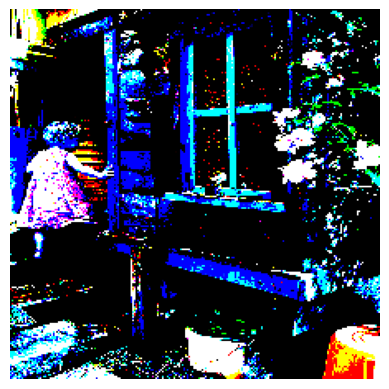

In [52]:
img = preprocess_img("/kaggle/input/flicker/Flickr8k_Dataset/Flicker8k_Dataset/1000268201_693b08cb0e.jpg")
plt.imshow(img[0])
plt.axis("off")
plt.show()

In [53]:
# def encode_image(img):
#     img = preprocess_img(img)
#     feature_vector = model.predict(img)#model_new.predict(img)
#     # feature_vector = feature_vector.reshape((2048,))
#     #print(feature_vector.shape)
#     return feature_vector

In [54]:
# encode_image("/kaggle/input/flicker/Flickr8k_Dataset/Flicker8k_Dataset/1000268201_693b08cb0e.jpg").shape

In [55]:
def encode_image(img):
    img = preprocess_img(img)
    feature_vector = model_new.predict(img)
    feature_vector = feature_vector.reshape((2048,))
    #print(feature_vector.shape)
    return feature_vector

🔹 What happens before reshape

When you call:

feature_vector = model_new.predict(img)


img has shape (1, 224, 224, 3) (batch of 1 image).

model_new outputs a feature vector per image (after GlobalAveragePooling2D).

So the result has shape (1, 2048).

1 = batch dimension.

2048 = features from ResNet-50.

🔹 Why reshape is used

(1, 2048) is a 2D array: one row, 2048 columns.
But for most downstream tasks (like storing features in a dictionary, passing to LSTM, etc.), you just want a 1D vector of length 2048.

So:

feature_vector.reshape((2048,))


removes the batch dimension, converting (1, 2048) → (2048,).

🔹 Example
import numpy as np
arr = np.array([[1,2,3,4]])   # shape (1,4)
print(arr.shape)  # (1,4)

flat = arr.reshape((4,))
print(flat.shape) # (4,)
print(flat)       # [1 2 3 4]


So after reshape, you just have a flat vector.

🔹 Why this is important

If you keep (1,2048), you’d be carrying an extra useless dimension everywhere.

Flattening to (2048,) makes it easy to:

Save feature vectors in a dictionary like {image_id: features}.

Concatenate with other vectors (like word embeddings).

Feed directly into a decoder that expects a 1D feature vector.

In [56]:
a=encode_image("/kaggle/input/flicker/Flickr8k_Dataset/Flicker8k_Dataset/1000268201_693b08cb0e.jpg")
a

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


array([0.06536549, 0.1678271 , 0.32518435, ..., 0.05111533, 0.32817906,
       1.0043344 ], dtype=float32)

In [57]:
a.shape

(2048,)

In [58]:
type(train)

list

In [47]:
'''
start = time()
encoding_train = {}
#image_id -->feature_vector extracted from Resnet Image
for ix,img_id in enumerate(train):
    img_path = '/kaggle/input/flicker/Flickr8k_Dataset/Flicker8k_Dataset'+"/"+img_id+".jpg"
    encoding_train[img_id] = encode_image(img_path)
    if ix%100==0:
        print("Encoding in progress time step %d "%ix)
end_t = time()
print("Total Time Taken :",end_t-start)
'''

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
Encoding in progress time step 0 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13

KeyboardInterrupt: 

# Just as the code written above i have encoded the train and test images using gpu and have saved them in the pickle file so directly i am loading them here instead of running above cell
# but for reference u can refer to above code that how we had written it encoding purposes

In [59]:
import pickle

# Load training features
with open("/kaggle/input/encoded-test-and-train-features-files/encoded_train_features.pkl", "rb") as f:
    encoding_train = pickle.load(f)

# Load test features
with open("/kaggle/input/encoded-test-and-train-features-files/encoded_test_features.pkl", "rb") as f:
    encoding_test = pickle.load(f)


In [60]:
encoding_train['2513260012_03d33305cf'].shape

(2048,)

# data preprocessing for captions

In [61]:
len(total_words)   # total_words is the vocabulary

1800

In [62]:
word_to_idx={}
idx_to_word={}

for i,word in enumerate(total_words):
    word_to_idx[word]=i+1
    idx_to_word[i+1]=word

In [63]:
word_to_idx['dog']


6

In [64]:
idx_to_word[2]

'the'

In [65]:
len(idx_to_word)
# len(word_to_idx)

1800

In [66]:

idx_to_word[1801] = 'startseq'
word_to_idx['startseq'] = 1801

idx_to_word[1802] = 'endseq'
word_to_idx['endseq'] = 1802

In [67]:
vocab_size =len(word_to_idx)+1
print(vocab_size)

1803


In [68]:

max_len = 0 
for key in train_descriptions.keys():
    for cap in train_descriptions[key]:
        max_len = max(max_len,len(cap.split()))
        
print(max_len)

30


In [69]:
# train_descriptions

In [70]:
# encoding_train

# Dataloader

In [71]:
from keras.utils import to_categorical

def data_generator(train_descriptions,encoding_train,word_to_idx,max_len,batch_size):
    X1,X2, y = [],[],[]
    
    n =0
    while True:
        for key,desc_list in train_descriptions.items():
            n += 1
            
            photo = encoding_train[key]
            for desc in desc_list:
                
                seq = [word_to_idx[word] for word in desc.split() if word in word_to_idx]
                for i in range(1,len(seq)):
                    xi = seq[0:i]
                    yi = seq[i]
                    
                    #0 denote padding word
                    xi = pad_sequences([xi],maxlen=max_len,value=0,padding='post')[0]
                    yi = to_categorical([yi],num_classes=vocab_size)[0]  # converting into a one hot encoder vector
                    
                    X1.append(photo)
                    X2.append(xi)
                    y.append(yi)
                    
                if n==batch_size:
                    # yield [[np.array(X1),np.array(X2)],np.array(y)]
                    yield ((np.array(X1, dtype=np.float32),
                                np.array(X2, dtype=np.int32)),
                               np.array(y, dtype=np.float32))   # yield a tuple not a list
                    X1,X2,y = [],[],[]
                    n = 0

In [72]:
f = open("/kaggle/input/glove-50d/glove.6B.50d.txt",encoding='utf8')

# How i can perform some basic operations on above f file that i have written below

When you do:

f = open("./saved/glove.6B.50d.txt", encoding='utf8')


f is now a file object pointing to your GloVe embeddings file.
To actually see what’s inside, you need to read from it.

🔹 Options to print the contents
1. Read the entire file (not recommended — huge file!)
print(f.read())


This will print the whole file as one long string.

⚠️ But glove.6B.50d.txt is very large (~170k lines), so it will flood your console.

2. Read line by line (safer)
for i, line in enumerate(f):
    if i < 5:   # just print first 5 lines
        print(line)
    else:
        break


This prints something like:

the 0.418 0.24968 -0.41242 0.1217 ...
of -0.70358 0.00339 -0.6063 -0.37818 ...
and 0.26818 0.14346 -0.27877 -0.062 ...


Each line = word + its 50-dimensional embedding vector.

3. Read first line only
print(f.readline())

4. Store all lines in memory
lines = f.readlines()
print(len(lines))  # number of words in the embeddings
print(lines[:3])   # first 3 entries


In [73]:
# type(f)

In [74]:
# for i, line in enumerate(f):
#     if i < 5:   # just print first 5 lines
#         print(line)
#     else:
#         break


In [75]:
embedding_index = {}

for line in f:
    values = line.split()
    word = values[0]
    word_embedding = np.array(values[1:],dtype='float')
    embedding_index[word] = word_embedding

In [76]:
# embedding_index

In [77]:
embedding_index['apple'] # embedding for apple

array([ 0.52042 , -0.8314  ,  0.49961 ,  1.2893  ,  0.1151  ,  0.057521,
       -1.3753  , -0.97313 ,  0.18346 ,  0.47672 , -0.15112 ,  0.35532 ,
        0.25912 , -0.77857 ,  0.52181 ,  0.47695 , -1.4251  ,  0.858   ,
        0.59821 , -1.0903  ,  0.33574 , -0.60891 ,  0.41742 ,  0.21569 ,
       -0.07417 , -0.5822  , -0.4502  ,  0.17253 ,  0.16448 , -0.38413 ,
        2.3283  , -0.66682 , -0.58181 ,  0.74389 ,  0.095015, -0.47865 ,
       -0.84591 ,  0.38704 ,  0.23693 , -1.5523  ,  0.64802 , -0.16521 ,
       -1.4719  , -0.16224 ,  0.79857 ,  0.97391 ,  0.40027 , -0.21912 ,
       -0.30938 ,  0.26581 ])

In [78]:
def get_embedding_matrix():
    emb_dim = 50
    matrix = np.zeros((vocab_size,emb_dim))   # making a 2d matrix to store the vector form for all vocabulary words
    for word,idx in word_to_idx.items():   # fetching the vector of that word
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            matrix[idx] = embedding_vector   # storing that vector into ihe index of that word

    return matrix

In [79]:
embedding_matrix=get_embedding_matrix()
embedding_matrix.shape

(1803, 50)

# Building final part of the model

In [80]:
input_img_features = Input(shape=(2048,))
inp_img1 = Dropout(0.3)(input_img_features)
inp_img2 = Dense(256,activation='relu')(inp_img1)

In [81]:

# Captions as Input
input_captions = Input(shape=(max_len,))
inp_cap1 = Embedding(input_dim=vocab_size,output_dim=50,mask_zero=True)(input_captions)
inp_cap2 = Dropout(0.3)(inp_cap1)
inp_cap3 = LSTM(256)(inp_cap2)

In [82]:
from keras.layers import add

decoder1 = add([inp_img2,inp_cap3])
decoder2 = Dense(256,activation='relu')(decoder1)
outputs = Dense(vocab_size,activation='softmax')(decoder2)

# Combined Model
model = Model(inputs=[input_img_features,input_captions],outputs=outputs)

In [83]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 30)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, 2048)           │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding (Embedding)     │ (None, 30, 50)         │         90,150 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 2048)           │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 30, 50)         │              0 │ embedding[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ not_equal (NotEqual)      │ (None, 30)             │              0 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 256)            │        524,544 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm (LSTM)               │ (None, 256)            │        314,368 │ dropout_1[0][0],       │
│                           │                        │                │ not_equal[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 256)            │              0 │ dense[0][0],           │
│                           │                        │                │ lstm[0][0]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 256)            │         65,792 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 1803)           │        463,371 │ dense_1[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 1,458,225 (5.56 MB)

 Trainable params: 1,458,225 (5.56 MB)

 Non-trainable params: 0 (0.00 B)

In [84]:
# Embedding Layer most important
model.layers[2].set_weights([embedding_matrix])
model.layers[2].trainable = False

* categorical_crossentropy is used with large no. of classes 

In [85]:
# model.compile(loss='categorical_crossentropy',optimizer="adam")

model.compile(loss='categorical_crossentropy',optimizer='adam')

In [143]:
# model training 
epochs = 50
batch_size = 3
steps = len(train_descriptions)//64
# print(steps)

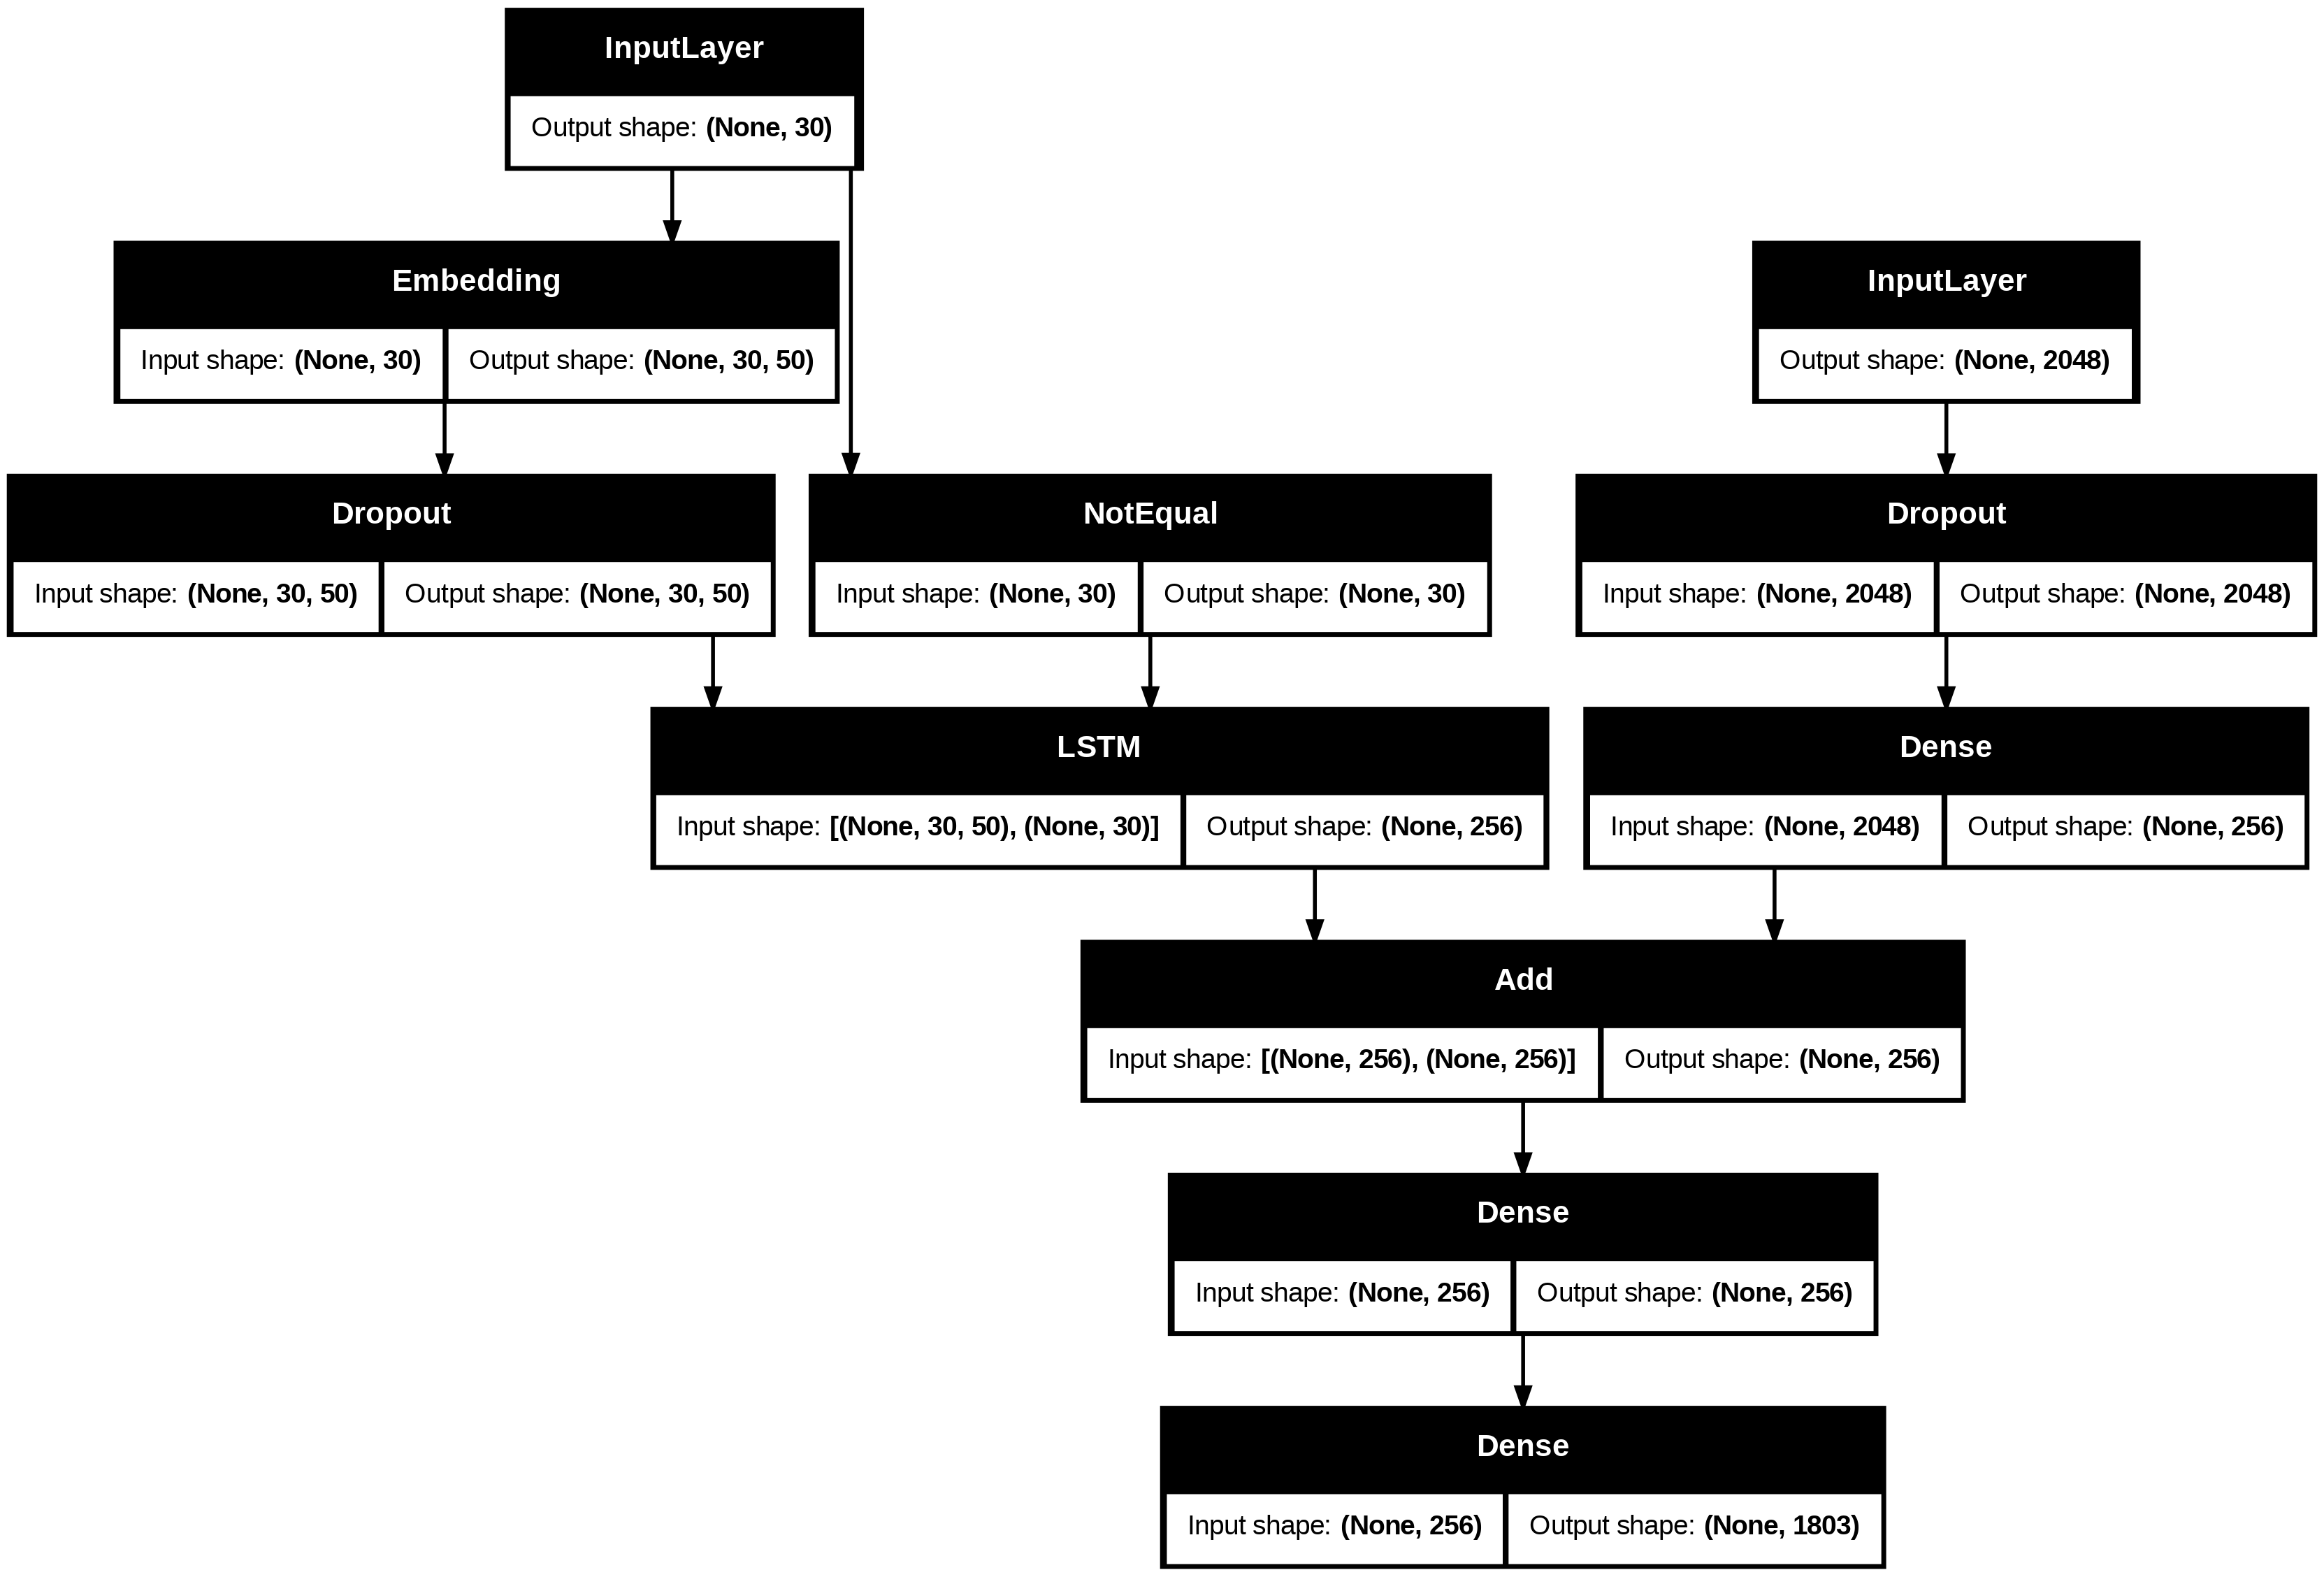

In [144]:
import tensorflow as tf
import pydot
import graphviz
tf.keras.utils.plot_model(model, show_shapes=True)

Considering batch size to be 3 , at each step we would be training our for 1 batch , means 3 images with there respective captions . So , the number of pics per batch will be equal to batch_Size. hence, number of pics per batch is 3.

and steps = 1000 //3 = 33 ( assuming your len( train_descriptions ) = 1000 )

In [145]:
def train():
    
    for i in range(epochs):
        generator = data_generator(train_descriptions,encoding_train,word_to_idx,max_len,batch_size)
        model.fit(generator,epochs=1,steps_per_epoch=steps,verbose=1)
        model.save('./model_weights/model_'+str(i)+'.h5')

In [146]:
import tensorflow as tf, keras

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("Using keras from:", keras.__file__)


TensorFlow version: 2.18.0
Keras version: 3.8.0
Using keras from: /usr/local/lib/python3.11/dist-packages/keras/__init__.py


In [147]:
train()

93/93 ━━━━━━━━━━━━━━━━━━━━ 15s 163ms/step - loss: 1.4108
93/93 ━━━━━━━━━━━━━━━━━━━━ 15s 158ms/step - loss: 1.3575
93/93 ━━━━━━━━━━━━━━━━━━━━ 14s 154ms/step - loss: 1.2812
93/93 ━━━━━━━━━━━━━━━━━━━━ 15s 156ms/step - loss: 1.2338
93/93 ━━━━━━━━━━━━━━━━━━━━ 14s 155ms/step - loss: 1.1980
93/93 ━━━━━━━━━━━━━━━━━━━━ 15s 157ms/step - loss: 1.1630
93/93 ━━━━━━━━━━━━━━━━━━━━ 14s 155ms/step - loss: 1.1318
93/93 ━━━━━━━━━━━━━━━━━━━━ 14s 154ms/step - loss: 1.0877
93/93 ━━━━━━━━━━━━━━━━━━━━ 14s 154ms/step - loss: 1.0260
93/93 ━━━━━━━━━━━━━━━━━━━━ 15s 156ms/step - loss: 1.0048
93/93 ━━━━━━━━━━━━━━━━━━━━ 15s 157ms/step - loss: 0.9503
93/93 ━━━━━━━━━━━━━━━━━━━━ 14s 155ms/step - loss: 0.9230
93/93 ━━━━━━━━━━━━━━━━━━━━ 14s 155ms/step - loss: 0.9178
93/93 ━━━━━━━━━━━━━━━━━━━━ 15s 156ms/step - loss: 0.8712
93/93 ━━━━━━━━━━━━━━━━━━━━ 14s 154ms/step - loss: 0.8550
93/93 ━━━━━━━━━━━━━━━━━━━━ 14s 154ms/step - loss: 0.8469
93/93 ━━━━━━━━━━━━━━━━━━━━ 14s 154ms/step - loss: 0.8066
93/93 ━━━━━━━━━━━━━━━━━━━━ 14s 

In [148]:
import tensorflow as tf, keras

print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)
print("Using keras from:", keras.__file__)


TensorFlow version: 2.18.0
Keras version: 3.8.0
Using keras from: /usr/local/lib/python3.11/dist-packages/keras/__init__.py


In [109]:

# # --- define shim layers ---
# class NotEqual(tf.keras.layers.Layer):
#     def call(self, inputs):
#         if isinstance(inputs, (list, tuple)) and len(inputs) == 2:
#             a, b = inputs
#             return tf.math.not_equal(a, b)
#         return inputs  # pass-through if serialized differently

# class Equal(tf.keras.layers.Layer):
#     def call(self, inputs):
#         if isinstance(inputs, (list, tuple)) and len(inputs) == 2:
#             a, b = inputs
#             return tf.math.equal(a, b)
#         return inputs

# class Mul(tf.keras.layers.Layer):
#     def call(self, inputs):
#         if isinstance(inputs, (list, tuple)) and len(inputs) == 2:
#             a, b = inputs
#             return a * b
#         return inputs

In [112]:
# from tensorflow.keras.models import load_model
# model = load_model('/kaggle/working/model_weights/model_9.h5')

# from tensorflow.keras.models import load_model
# import tensorflow as tf


model = load_model('/kaggle/working/model_weights/model_49.h5')

# not working


# FINAL PREDICTIONS

In [149]:
def predict_caption(photo):
    
    in_text = "startseq"
    for i in range(max_len):
        sequence = [word_to_idx[w] for w in in_text.split() if w in word_to_idx]
        sequence = pad_sequences([sequence],maxlen=max_len,padding='post')
        final_caption = set()
        ypred = model.predict([photo,sequence])
        ypred = ypred.argmax() 
        word = idx_to_word[ypred]
        in_text = ' ' + word
        final_caption.add(in_text)
        
        print(in_text)
        
        if word == "endseq":
            break
    
#         final_caption = in_text.split()[1:-1]
        st = ' '.join(final_caption)
        final_caption.clear()
    
    return st

In [121]:
# # Pick Some Random Images and See Results
# plt.style.use("seaborn")
# for i in range(15):
#     idx = np.random.randint(0,1000)
#     all_img_names = list(encoding_test.keys())
#     img_name = all_img_names[idx]
#     photo_2048 = encoding_test[img_name].reshape((1,2048))
    
#     i = plt.imread("/kaggle/input/photos/taxidriver.png")
    
#     caption=' '.join(predict_caption(photo_2048))
#     #print(caption)
    
# plt.title(caption)
# plt.imshow(i)
# plt.axis("off")
# plt.show()
    

In [150]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_caption(photo_vec, model, word_to_idx, idx_to_word, max_len):
    """
    photo_vec: shape (1, 2048) float32
    model: your captioning model (two inputs: photo_vec, seq)
    word_to_idx / idx_to_word: vocabulary mappings (must include 'startseq','endseq')
    max_len: max caption length used in training
    """
    in_text = "startseq"
    for _ in range(max_len - 1):
        # map current text to indices
        seq = [word_to_idx[w] for w in in_text.split() if w in word_to_idx]
        seq = pad_sequences([seq], maxlen=max_len, padding='post', value=0)

        # predict next word (SILENCE progress bars)
        yhat = model.predict([photo_vec, seq], verbose=0)
        next_id = int(np.argmax(yhat[0]))

        # map id -> word
        next_word = idx_to_word.get(next_id)
        if next_word is None:  # unknown id, stop
            break

        in_text += " " + next_word
        if next_word == "endseq":
            break

    # clean up: drop start/end tokens
    words = in_text.split()
    if words and words[0] == "startseq":
        words = words[1:]
    if words and words[-1] == "endseq":
        words = words[:-1]
    return " ".join(words)


In [124]:
# import os
# import matplotlib.pyplot as plt
# plt.style.use("seaborn")

# results = []

# # all_img_names = list(encoding_test.keys())  # keys like 'xxxx.jpg'
# # for _ in range(15):
#     # idx = np.random.randint(0, len(all_img_names))
#     # img_name = all_img_names[idx]

#     # get 2048-d features and ensure correct shape/dtype
#     # photo_2048 = np.asarray(encoding_test[img_name], dtype=np.float32).reshape(1, 2048)

#     # (optional) show the actual image instead of a fixed file:
#     # TEST_IMAGES_DIR should be the folder where your test images live
#     # img_path = os.path.join(TEST_IMAGES_DIR, img_name)
#     # img_disp = plt.imread(img_path)

#     # if you want to keep showing the fixed taxi image, keep your line instead:
#     img_disp = plt.imread("/kaggle/input/photos/taxidriver.png")

#     caption = predict_caption(photo_2048, model, word_to_idx, idx_to_word, max_len)

#     # # display
#     # plt.figure()
#     # plt.imshow(img_disp)
#     # plt.title(caption)
#     # plt.axis("off")
#     # plt.show()

#     # collect for saving
#     results.append({"image": img_name, "caption": caption})

# # save all predicted captions to a CSV
# import pandas as pd
# pd.DataFrame(results).to_csv("predicted_captions.csv", index=False)
# print("Saved predicted captions to predicted_captions.csv")


/tmp/ipykernel_36/3653623451.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn")


Saved predicted captions to predicted_captions.csv


In [127]:
# len(results)

15

In [151]:
def extract_features(img_path, model_new):
    """Extract 2048-dim feature from image using ResNet50 GAP layer."""
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)  # same preprocessing as training
    feature = model_new.predict(x, verbose=0)
    return feature


In [152]:
img_path1 = "/kaggle/input/photos/taxidriver.png"  # replace with your own uploaded image

def predicting(img_path):
    photo_vec = extract_features(img_path, model_new)  # shape (1, 2048)
    
    
    
    caption = predict_caption(photo_vec, model, word_to_idx, idx_to_word, max_len)
    
    # Show image with caption
    plt.imshow(image.load_img(img_path))
    plt.title(caption)
    plt.axis("off")
    plt.show()
    
    print("Generated Caption:", caption)

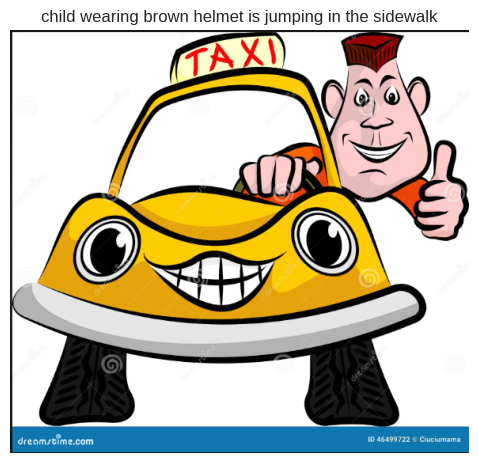

Generated Caption: child wearing brown helmet is jumping in the sidewalk


In [153]:
predicting(img_path1)

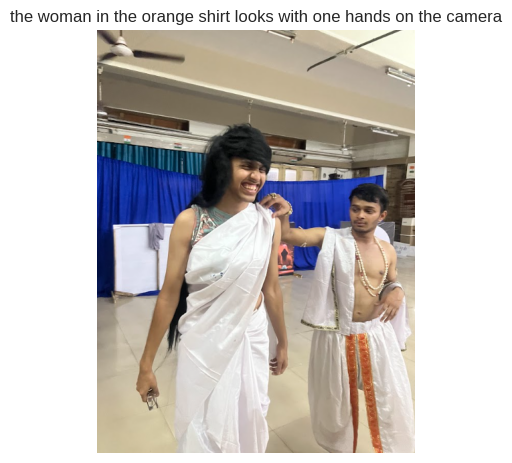

Generated Caption: the woman in the orange shirt looks with one hands on the camera


In [154]:
predicting('/kaggle/input/photos/30.11.2024_01.25.34_REC.png')

In [156]:
!zip -r /kaggle/working/model_weights.zip /kaggle/working/model_weights


  adding: kaggle/working/model_weights/ (stored 0%)
  adding: kaggle/working/model_weights/model_4.h5 (deflated 7%)
  adding: kaggle/working/model_weights/model_49.h5 (deflated 7%)
  adding: kaggle/working/model_weights/model_22.h5 (deflated 7%)
  adding: kaggle/working/model_weights/model_43.h5 (deflated 7%)
  adding: kaggle/working/model_weights/model_28.h5 (deflated 7%)
  adding: kaggle/working/model_weights/model_23.h5 (deflated 7%)
  adding: kaggle/working/model_weights/model_21.h5 (deflated 7%)
  adding: kaggle/working/model_weights/model_2.h5 (deflated 7%)
  adding: kaggle/working/model_weights/model_30.h5 (deflated 7%)
  adding: kaggle/working/model_weights/model_45.h5 (deflated 7%)
  adding: kaggle/working/model_weights/model_27.h5 (deflated 7%)
  adding: kaggle/working/model_weights/model_33.h5 (deflated 7%)
  adding: kaggle/working/model_weights/model_37.h5 (deflated 7%)
  adding: kaggle/working/model_weights/model_48.h5 (deflated 7%)
  adding: kaggle/working/model_weights/m

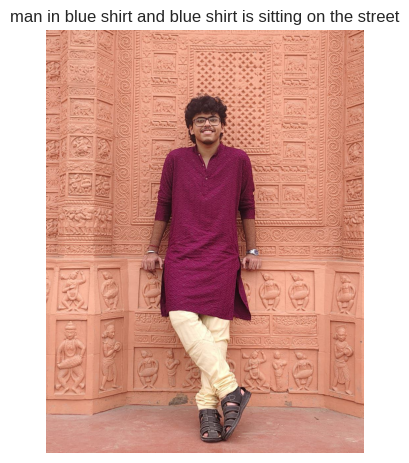

Generated Caption: man in blue shirt and blue shirt is sitting on the street


In [158]:
predicting('/kaggle/input/photos/nandi.jpg')

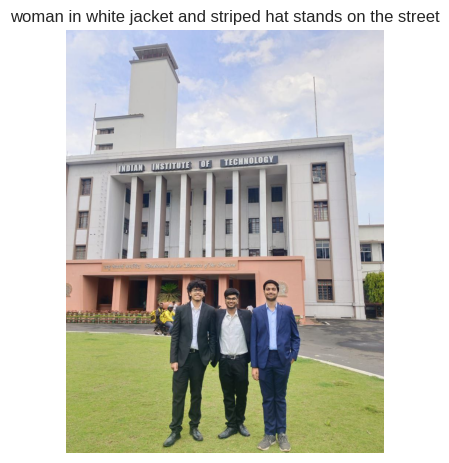

Generated Caption: woman in white jacket and striped hat stands on the street


In [159]:
predicting('/kaggle/input/photos/6129557710744701573_121.jpg')

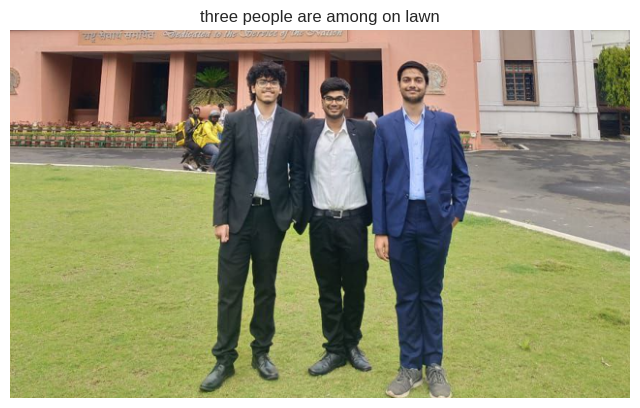

Generated Caption: three people are among on lawn


In [160]:
predicting('/kaggle/input/photos/Screenshot 2025-08-17 165128.png')